In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lightgbm import LGBMRegressor

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

print(train_df.shape)

(61249, 54)


In [3]:
RUL_CAP = 125

train_df["RUL_capped"] = (
    train_df["RUL"]
    .clip(upper=RUL_CAP)
)

In [4]:
DROP_COLS = [
    "unit_number",
    "RUL",
    "RUL_capped",
    "max_cycle",
    "life_fraction"
]

features = [
    col
    for col in train_df.columns
    if col not in DROP_COLS
]

X = train_df[features]
y = train_df["RUL_capped"]

In [5]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(
        X,
        y,
        groups=train_df["unit_number"]
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [6]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9133
[LightGBM] [Info] Number of data points in the train set: 49294, number of used features: 48
[LightGBM] [Info] Start training from score 93.208606


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [7]:
preds = model.predict(
    X_val
)

In [8]:
mae = mean_absolute_error(
    y_val,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        preds
    )
)

r2 = r2_score(
    y_val,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 12.697964719118817
RMSE: 19.355016056556796
R²  : 0.7757948408210716


In [9]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(20)

,feature,importance
0,time_cycle,1964
33,sensor_11_norm,804
29,sensor_6_norm,711
36,sensor_14_norm,681
34,sensor_12_norm,615
27,sensor_4_norm,613
32,sensor_9_norm,612
30,sensor_7_norm,581
31,sensor_8_norm,524
25,sensor_2_norm,488


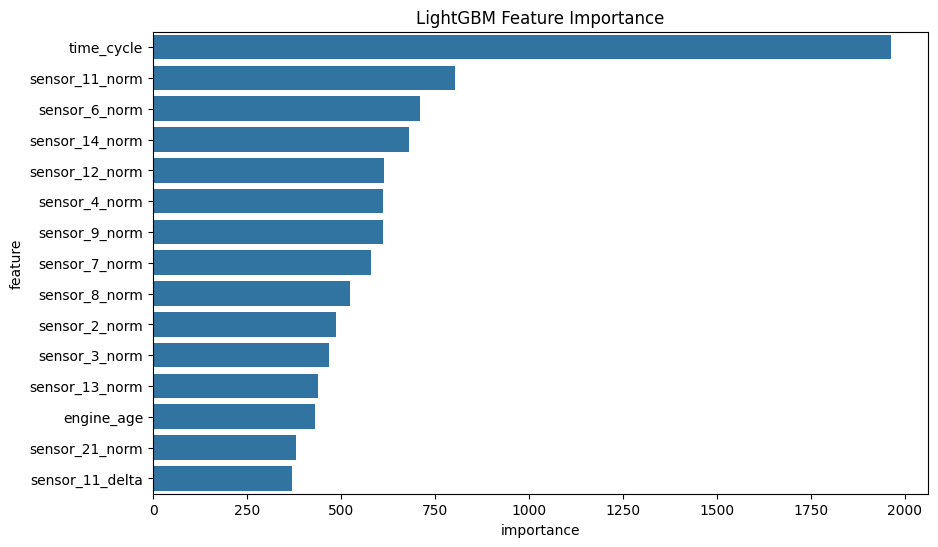

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title(
    "LightGBM Feature Importance"
)

plt.show()

In [13]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "MAE": [12.70, 12.70],
    "RMSE": [19.38, 19.35],
    "R2": [0.775, 0.776]
})

comparison

,Model,MAE,RMSE,R2
0,XGBoost,12.7,19.38,0.775
1,LightGBM,12.7,19.35,0.776


In [12]:
importance.head(15)

,feature,importance
0,time_cycle,1964
33,sensor_11_norm,804
29,sensor_6_norm,711
36,sensor_14_norm,681
34,sensor_12_norm,615
27,sensor_4_norm,613
32,sensor_9_norm,612
30,sensor_7_norm,581
31,sensor_8_norm,524
25,sensor_2_norm,488
